# L09/dataanalyse

## Qa Beskrivelse af datasæt til O4 projekt
For the O4 project we have chosen to investigate the reliabilty of flexible and wearable antennas. With the rise of wearable technoligies like smartwatches there is a massive demand for reliable hardware cabable of suriving a bit of sweat or a knock. Our goal will be to develop a machine learning model able to predict imminent fault cases and be a part of the maintenance and detection system. The machine learning model should be a classifier able to ascertain whether or not the wifi and or bluetooth is failing and also classify which kind of fault is present. To train our model we have chosen [This data set from kaggle.com](https://www.kaggle.com/datasets/amineipad/antenna-performance-and-fault-detection-dataset?fbclid=IwY2xjawQffuJleHRuA2FlbQIxMQBzcnRjBmFwcF9pZAEwAAEeJ2UxEK4SsTF78Us3f-ALRqmDz68CFkv2aszLsnn0NTB3mq0-Kfri-Ghet-M_aem_khEFRjyx4IXRwn4GQIPcEw), it should work well due to its comprehensive feature list and a sample size just over 1100. The features include Length, Width, Height, Permittivity, Conductivity, and epsilon_r. Alongside these physical traits, the dataset captures critical radio frequency (RF) performance indicators like Return Loss (S11), Voltage Standing Wave Ratio (VSWR), Gain, Efficiency, and Bandwidth. From the description of the dataset: "Crucially, the dataset features explicit classifications for various environmental and physical fault conditions—such as Humidity/Sweat, Bending, Cracks, and Rupture/Coupure—and tracks their impact on the operational status of both WiFi and BT functionalities. It is an excellent resource for predictive maintenance, anomaly detection, and robust wearable antenna design using machine learning." Furthermore we as a group hope this project will enable us to obtain a deeper understanding of antenna perfomance and the parameters related to this. The data in this set was "collected through a series of controlled simulations and empirical measurements that emulate real-world conditions for wearable antennas. Various physical deformations and environmental stressors were applied to the antenna models, including bending at different radii, introducing structural cracks or ruptures, and simulating changes in dielectric properties due to humidity or sweat." So we should have in mind that the data probably represents cleaner versions of the faults and is limited to these kinds of fault, not entirely covering the real world in which the wearable antennas would exist.
We intend to apply this dataset to perform Supervised Learning, as we are provided with the correct target labels (the operational status) for each antenna instance. Specifically, we will frame this problem as a Classification task. We will train an algorithm to predict the operational status, treating it as a binary classification problem (e.g., 1 for operational, 0 for defective) given the physical and electrical features. If time permits, we may expand this into a multiclass classification problem where we predict the specific failure mode. 
Given that some of the features have quite high values we will very likely have to use a pipeline and scale the data, depending of course on the type of model we ultimately choose to employ.

   Length  Width  Height  Permittivity  Conductivity  Bend   Feed    S11  \
0   46.72  38.62    1.46          1.51      12210.65  0.56 -10.27  -7.09   
1   40.32  36.17    1.30          1.61       9589.73  0.48 -17.33  -7.92   
2   43.84  35.89    1.17          1.53       4067.44  0.99 -11.95 -18.97   
3   43.77  39.46    1.26          1.88      13052.58  0.67 -10.07 -12.89   
4   46.48  39.66    1.30          2.44      12682.11  1.08 -17.57 -22.94   

   VSWR  Gain  Efficiency  Bandwidth       WiFi Fault        BT Fault  \
0  3.41  5.09       62.26     102.74           Cracks          Cracks   
1  2.47  5.17       66.61      96.06  Rupture_Coupure        No_Fault   
2  3.20  5.07       83.42     150.03          Bending  Strong_Flexion   
3  1.72  3.83       42.22      54.23      Body_Effect         Coupure   
4  1.44  3.48       77.39      93.00   Strong_Flexion        No_Fault   

  WiFi Status BT Status  epsilon_r  
0       Fault     Fault       3.90  
1       Fault    Normal       

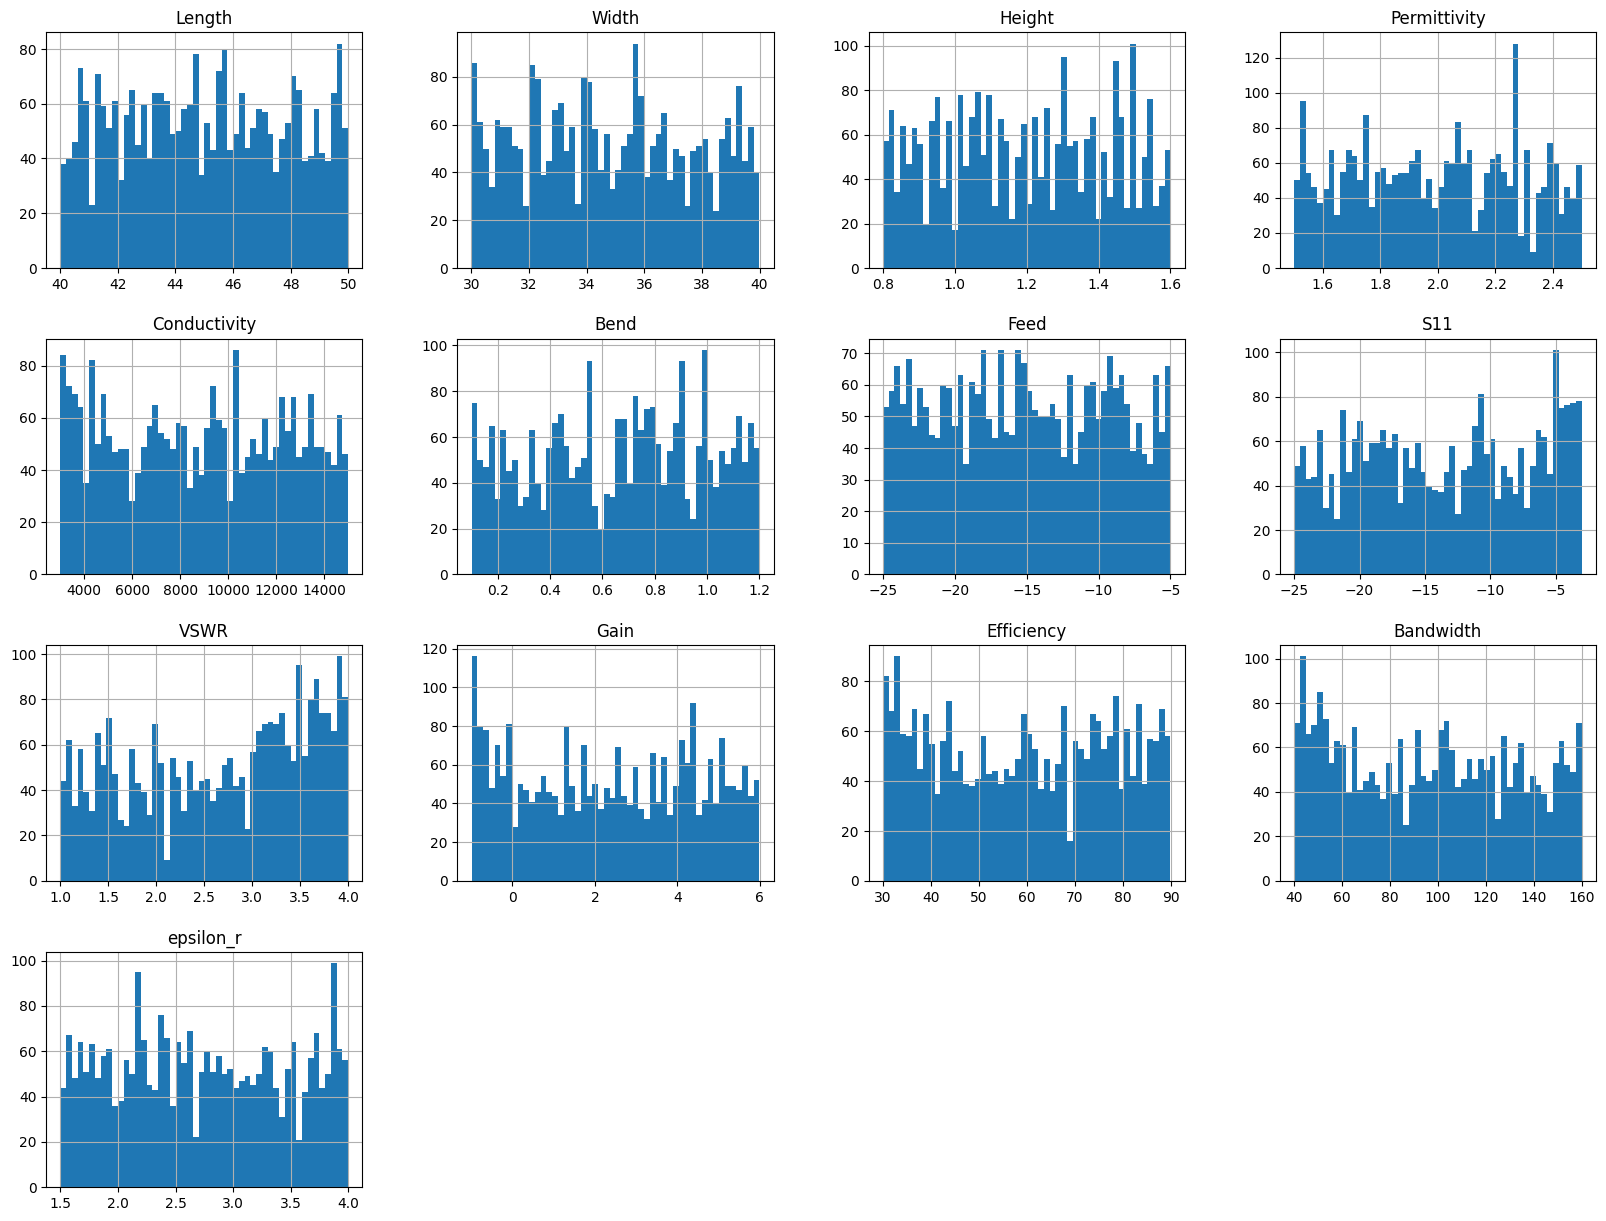

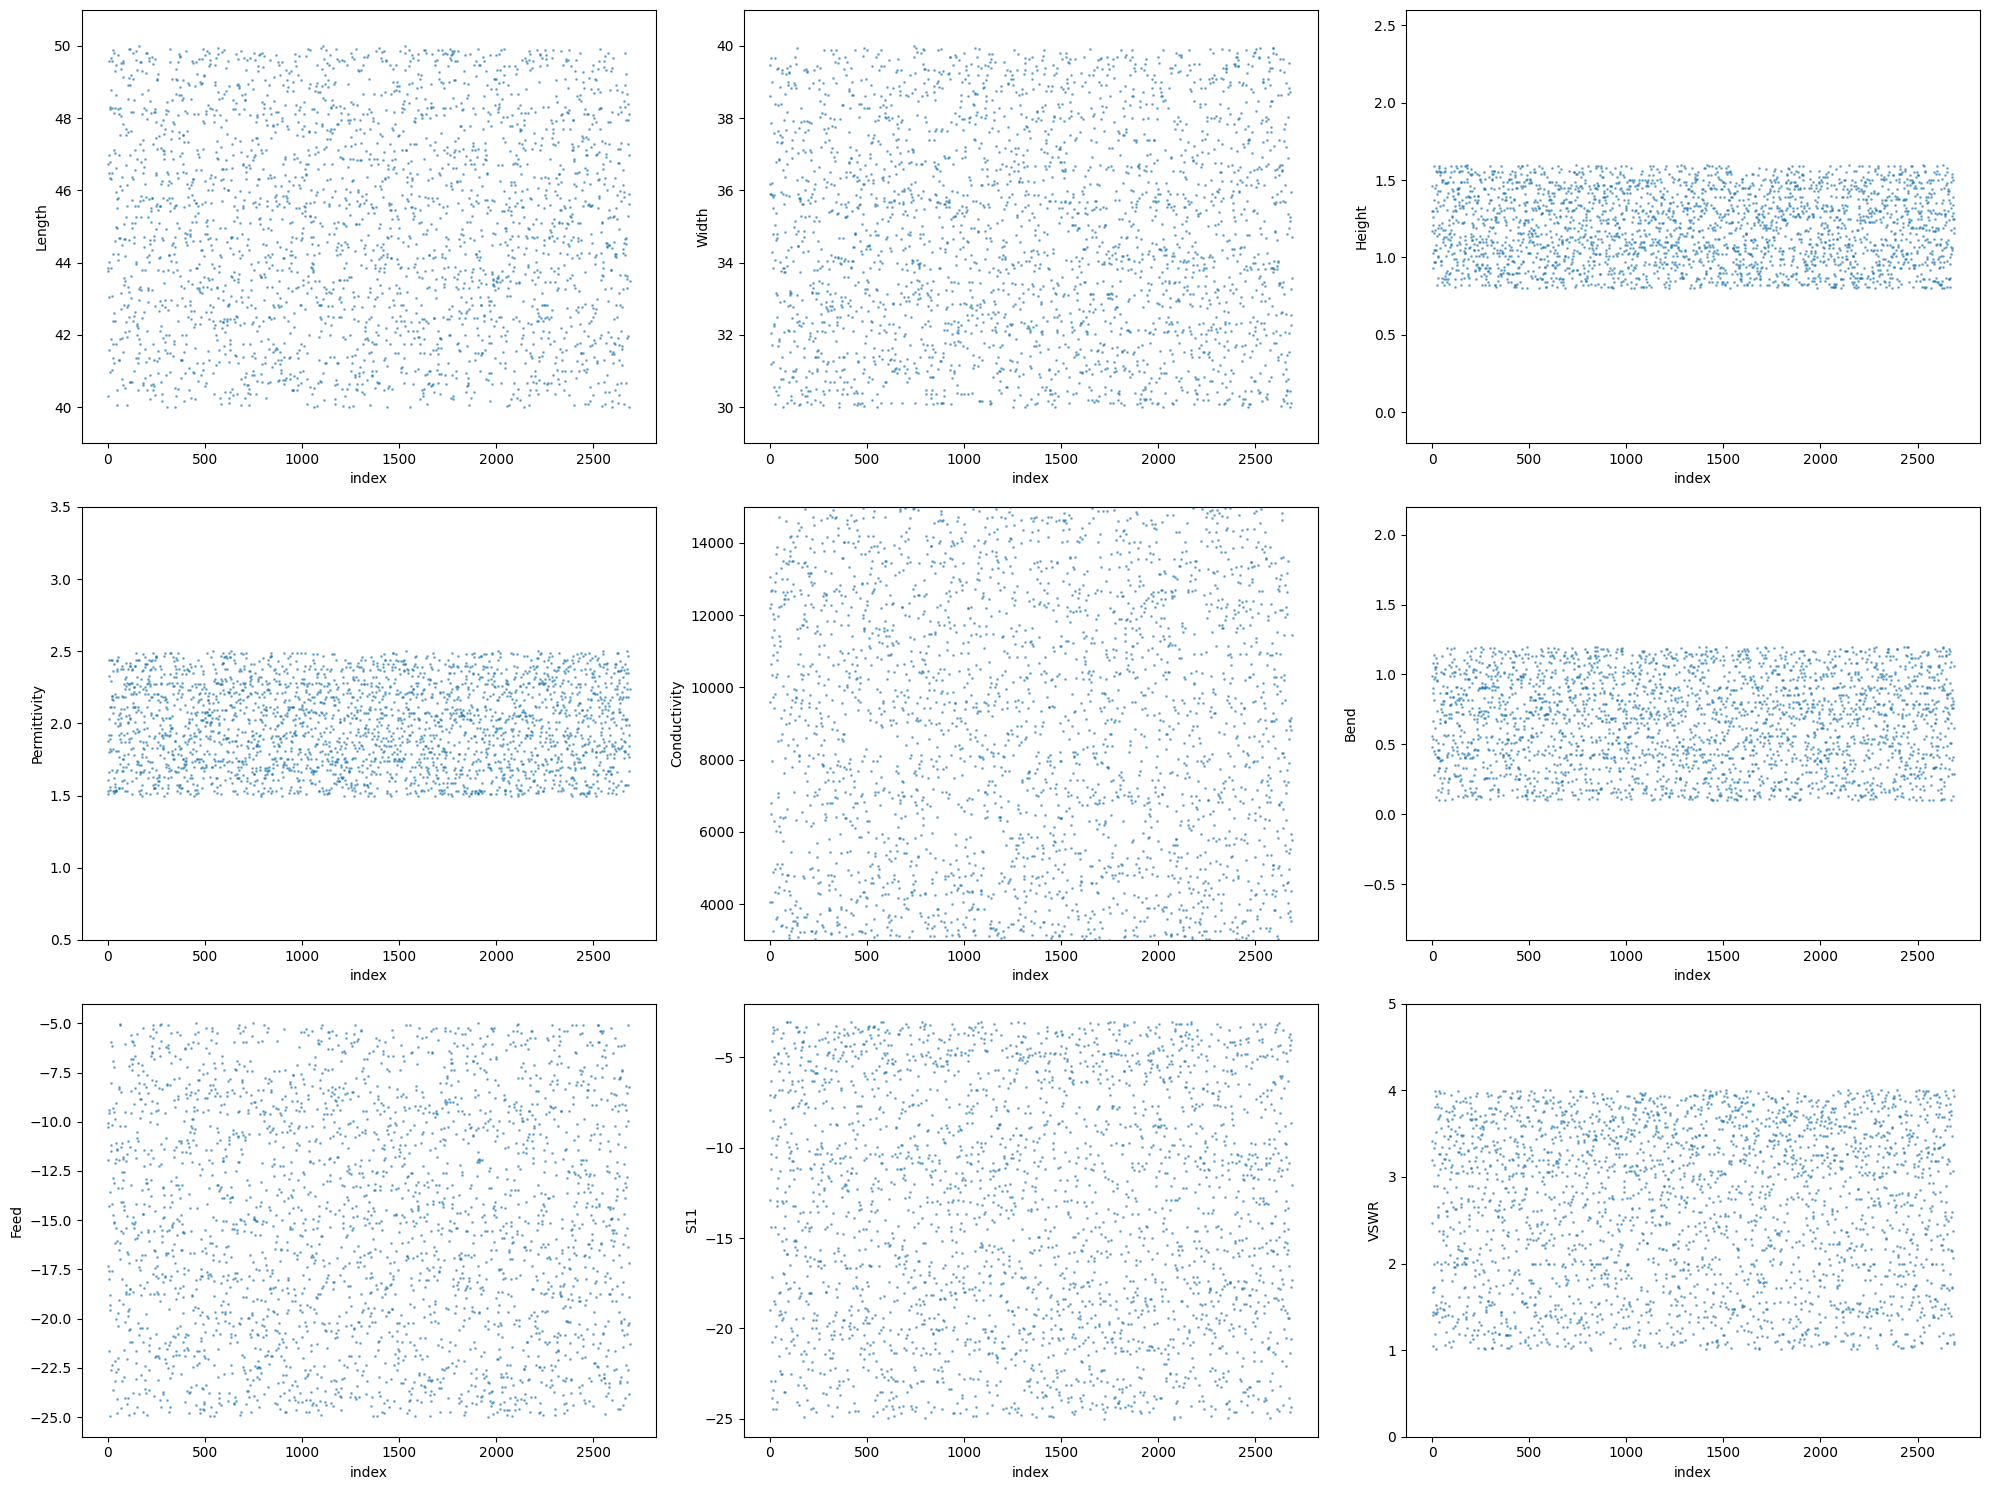

From the plots we see that there does not seem to be singular outliers to be concerned about, there is however for some features 
a quite large relative deviation from minimun values to maximum 
Furthermore we see that the controlled enviroment has resulted in pretty firm limits of the data. We see on the histograms 
that the data is clearly not normal, which is a good sign for the real life mimicing.


In [ ]:
# Importing the data
import pandas as pd
import os

Bat_dat = "antenna_fault.csv"

# Load the data into a DataFrame
df = pd.read_csv(Bat_dat)

print(df.head()) #Prints the first five rows to get an idea of how the dataset looks
print(df.info()) #Prints some infomation about the data and their type (String/float)
print(df.describe()) #Prints count, mean, standar deviation, and the quatiles for each feature

import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(20,15))
plt.show()

df_plot = df.reset_index()

#Scatterplotting the data to look for outliers
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
axes = axes.flatten()

numeric_cols = df.select_dtypes(include=['number']).columns

for i, col in enumerate(numeric_cols[:9]):
    df_plot.plot(kind='scatter', x='index', y=col, ax=axes[i], s=1, alpha=0.5)
    axes[i].set_ylim(df[col].min() -1, (df[col].max()) + 1)

plt.tight_layout()
plt.show()

print("From the plots we see that there does not seem to be singular outliers to be concerned about, there is however for some features " \
"\na quite large relative deviation from minimun values to maximum " \
"\nFurthermore we see that the controlled enviroment has resulted in pretty firm limits of the data. We see on the histograms " \
"\nthat the data is clearly not normal, which is a good sign for the real life mimicing.")